# 07 Cost-Sensitive XGBoost Tuning

This notebook keeps the `v2_full` preprocessing fixed and tunes the **model on top of those fixed features**.

So this is not another preprocessing ablation. The feature engineering is already chosen. The question now is whether a cost-sensitive XGBoost configuration can beat the earlier untuned `v2_full` reference on the same time-based validation design.

Business logic first:

- `false negative`: a real fraud case that the model misses
- `false positive`: a legitimate transaction that gets flagged and can still go through a confirmation or review step

That means it is reasonable to make fraud misses more costly. In this notebook that cost-sensitive behavior is implemented by increasing the effective positive-class weight through `scale_pos_weight`.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import shap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.cost_sensitive_experiments import (
    PRIMARY_METRIC,
    SECONDARY_METRICS,
    DIAGNOSTIC_METRICS,
    build_run_summary,
    build_shap_diagnostics,
    fit_cost_sensitive_xgboost,
    prepare_cost_sensitive_data,
    run_named_configs,
    run_weight_sweep,
)
from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

SAMPLE_SIZE = 80_000
RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 1_200
WEIGHT_MULTIPLIERS = [0.65, 0.75, 0.85]
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Matplotlib is building the font cache; this may take a moment.


## Evaluation Setup

The notebook uses a business-facing ranking objective rather than optimizing only for a single generic metric.

- `Primary metric`: `Precision@Top3%`
- `Secondary metrics`: `Recall@Top3%`, `Average Precision`
- `Diagnostics`: `Precision@Top1%`, `Precision@Top5%`, `ROC-AUC`


In [2]:
data_bundle = prepare_cost_sensitive_data(
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

run_summary = build_run_summary(data_bundle)
display(run_summary.style.hide(axis="index"))

print(f"Primary metric: {PRIMARY_METRIC}")
print(f"Secondary metrics: {', '.join(SECONDARY_METRICS)}")
print(f"Diagnostics: {', '.join(DIAGNOSTIC_METRICS)}")


item,value
sample_rows,80000.000000
train_rows,64000.000000
validation_rows,16000.000000
train_fraud_rate,0.035562
validation_fraud_rate,0.035687
base_scale_pos_weight,27.119508
feature_count,807.000000


Primary metric: precision_at_top_3pct
Secondary metrics: recall_at_top_3pct, average_precision
Diagnostics: precision_at_top_1pct, precision_at_top_5pct, roc_auc


## Untuned `v2_full` Reference

Before tuning anything, it helps to pin down the untuned `v2_full` reference. This run uses the same fixed `v2_full` feature set as the rest of the notebook and mirrors the earlier `06` style XGBoost setup as closely as possible.

That way the final conclusion can answer the question that matters most: is the best cost-sensitive model actually better than the earlier untuned `v2_full` baseline?


In [3]:
reference_result = fit_cost_sensitive_xgboost(
    data_bundle,
    pos_weight_multiplier=1.0,
    label="v2_full_reference_untuned",
    param_overrides={
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "min_child_weight": 1,
        "reg_alpha": 0.0,
        "gamma": 0.0,
    },
)

reference_row = reference_result["row"]
display(
    pd.DataFrame([reference_row])[
        [
            "label",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "average_precision",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
            "roc_auc",
            "scale_pos_weight",
        ]
    ].style.hide(axis="index")
)

previous_v2_results_path = OUTPUT_DIR / "tree_ablation_v2_results.json"
if previous_v2_results_path.exists():
    previous_v2_results = pd.DataFrame(json.loads(previous_v2_results_path.read_text(encoding="utf-8")))
    display(previous_v2_results.style.hide(axis="index"))


label,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc,scale_pos_weight
v2_full_reference_untuned,0.525000,0.441331,0.472785,0.850000,0.373750,0.891387,27.119508


## Step 1: Narrow Cost-Sensitive Sweep

The first step only tunes the fraud-class weight. It does not touch the rest of the model capacity.

- `base_ratio = n_negative / n_positive`
- `scale_pos_weight = base_ratio * multiplier`
- the multiplier is applied to the positive fraud class weight, not used as a raw class weight

Here the notebook checks `0.65`, `0.75`, and `0.85`.


label,pos_weight_multiplier,scale_pos_weight,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc
previous_weight_x0.6,0.600000,16.271705,0.522917,0.439580,0.480077,0.812500,0.393750,0.892649
weight_x0.65,0.650000,17.627680,0.522917,0.439580,0.480199,0.831250,0.393750,0.894435
weight_x0.75,0.750000,20.339631,0.518750,0.436077,0.473085,0.812500,0.386250,0.893227
weight_x0.85,0.850000,23.051582,0.512500,0.430823,0.472940,0.812500,0.383750,0.892677


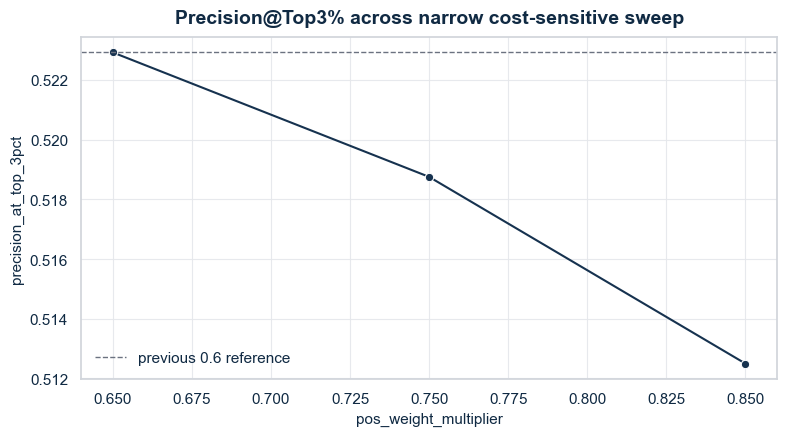

In [4]:
weight_results, weight_artifacts = run_weight_sweep(
    data_bundle,
    multipliers=WEIGHT_MULTIPLIERS,
)

previous_weight_reference = pd.DataFrame(
    [
        {
            "label": "previous_weight_x0.6",
            "pos_weight_multiplier": 0.6,
            "scale_pos_weight": 16.271705,
            "precision_at_top_3pct": 0.522917,
            "recall_at_top_3pct": 0.439580,
            "average_precision": 0.480077,
            "precision_at_top_1pct": 0.812500,
            "precision_at_top_5pct": 0.393750,
            "roc_auc": 0.892649,
        }
    ]
)
weight_display = pd.concat([previous_weight_reference, weight_results], ignore_index=True, sort=False)

display(
    weight_display[
        [
            "label",
            "pos_weight_multiplier",
            "scale_pos_weight",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "average_precision",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
            "roc_auc",
        ]
    ].style.hide(axis="index")
)

best_weight_row = weight_results.iloc[0]
best_weight_multiplier = float(best_weight_row["pos_weight_multiplier"])

plt.figure(figsize=(8, 4.5))
sns.lineplot(
    data=weight_results.sort_values("pos_weight_multiplier"),
    x="pos_weight_multiplier",
    y="precision_at_top_3pct",
    marker="o",
    color=PLOT_COLORS["navy"],
)
plt.axhline(
    previous_weight_reference.loc[0, "precision_at_top_3pct"],
    linestyle="--",
    color=PLOT_COLORS["muted"],
    linewidth=1,
    label="previous 0.6 reference",
)
plt.title("Precision@Top3% across narrow cost-sensitive sweep")
plt.xlabel("pos_weight_multiplier")
plt.ylabel("precision_at_top_3pct")
plt.legend()
plt.tight_layout()
plt.show()


## Step 2: Targeted Hyperparameter Search

After the weight sweep, keep the best positive-class multiplier fixed and compare a compact set of XGBoost configurations around model capacity, sampling, and regularization.


label,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,gamma,scale_pos_weight
deeper_depth8_lr03_700,0.550000,0.462347,0.499953,0.825000,0.398750,0.895907,700,8,0.030000,0.800000,0.700000,3.000000,2.000000,0.100000,0.000000,17.627680
more_capacity_depth7_lr03_800,0.545833,0.458844,0.487448,0.825000,0.386250,0.892994,800,7,0.030000,0.800000,0.700000,3.000000,2.000000,0.100000,0.000000,17.627680
balanced_depth6_lr05_500,0.545833,0.458844,0.486632,0.825000,0.395000,0.894555,500,6,0.050000,0.800000,0.800000,5.000000,2.000000,0.000000,0.000000,17.627680
wide_sampling_depth7_lr03_800,0.529167,0.444834,0.487392,0.837500,0.388750,0.895371,800,7,0.030000,0.850000,0.850000,3.000000,2.000000,0.100000,0.000000,17.627680
precision_push_depth4_lr08,0.529167,0.444834,0.465407,0.818750,0.370000,0.891119,450,4,0.080000,0.700000,0.600000,8.000000,5.000000,1.000000,1.000000,17.627680
regularized_depth6_lambda5,0.527083,0.443082,0.483130,0.831250,0.391250,0.897710,700,6,0.030000,0.800000,0.700000,5.000000,5.000000,0.100000,0.000000,17.627680
conservative_sampling_depth5,0.518750,0.436077,0.478054,0.812500,0.385000,0.894281,700,5,0.030000,0.700000,0.600000,5.000000,5.000000,0.100000,0.000000,17.627680
strong_regularization_depth5,0.516667,0.434326,0.474281,0.837500,0.383750,0.893841,600,5,0.050000,0.850000,0.800000,8.000000,10.000000,0.500000,0.500000,17.627680


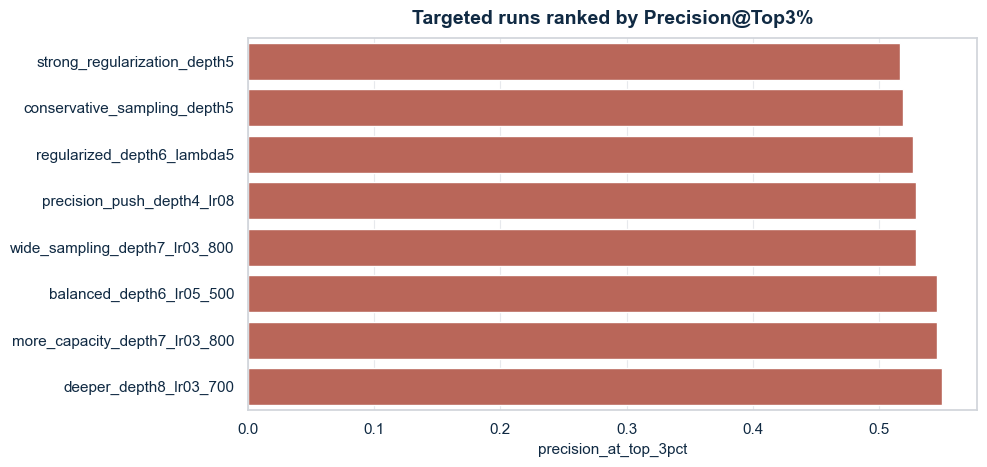

In [5]:
tuning_blueprint = [
    ("balanced_depth6_lr05_500", 500, 6, 0.05, 0.80, 0.80, 5, 2.0, 0.0, 0.0),
    ("more_capacity_depth7_lr03_800", 800, 7, 0.03, 0.80, 0.70, 3, 2.0, 0.1, 0.0),
    ("deeper_depth8_lr03_700", 700, 8, 0.03, 0.80, 0.70, 3, 2.0, 0.1, 0.0),
    ("wide_sampling_depth7_lr03_800", 800, 7, 0.03, 0.85, 0.85, 3, 2.0, 0.1, 0.0),
    ("regularized_depth6_lambda5", 700, 6, 0.03, 0.80, 0.70, 5, 5.0, 0.1, 0.0),
    ("strong_regularization_depth5", 600, 5, 0.05, 0.85, 0.80, 8, 10.0, 0.5, 0.5),
    ("conservative_sampling_depth5", 700, 5, 0.03, 0.70, 0.60, 5, 5.0, 0.1, 0.0),
    ("precision_push_depth4_lr08", 450, 4, 0.08, 0.70, 0.60, 8, 5.0, 1.0, 1.0),
]

targeted_configs = [
    {
        "label": label,
        "pos_weight_multiplier": best_weight_multiplier,
        "params": {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "learning_rate": learning_rate,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "min_child_weight": min_child_weight,
            "reg_lambda": reg_lambda,
            "reg_alpha": reg_alpha,
            "gamma": gamma,
        },
    }
    for (
        label,
        n_estimators,
        max_depth,
        learning_rate,
        subsample,
        colsample_bytree,
        min_child_weight,
        reg_lambda,
        reg_alpha,
        gamma,
    ) in tuning_blueprint
]

targeted_results, targeted_artifacts = run_named_configs(
    data_bundle,
    configs=targeted_configs,
)

display(
    targeted_results[
        [
            "label",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "average_precision",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
            "roc_auc",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "min_child_weight",
            "reg_lambda",
            "reg_alpha",
            "gamma",
            "scale_pos_weight",
        ]
    ].style.hide(axis="index")
)

best_targeted_row = targeted_results.iloc[0]
best_targeted_result = targeted_artifacts[best_targeted_row["label"]]

plt.figure(figsize=(10, 4.8))
sns.barplot(
    data=targeted_results.iloc[::-1],
    x="precision_at_top_3pct",
    y="label",
    color=PLOT_COLORS["coral"],
)
plt.title("Targeted runs ranked by Precision@Top3%")
plt.xlabel("precision_at_top_3pct")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Final Comparison: Did The Tuned Model Actually Beat The Earlier `v2_full` Reference?

This is the most important summary view in the notebook. It puts the final tuned winner directly beside the untuned `v2_full` reference.


label,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc
v2_full_reference_untuned,0.525000,0.441331,0.472785,0.850000,0.373750,0.891387
deeper_depth8_lr03_700,0.550000,0.462347,0.499953,0.825000,0.398750,0.895907


comparison,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc
best_targeted_minus_reference,0.025000,0.021016,0.027168,-0.025000,0.025000,0.004520


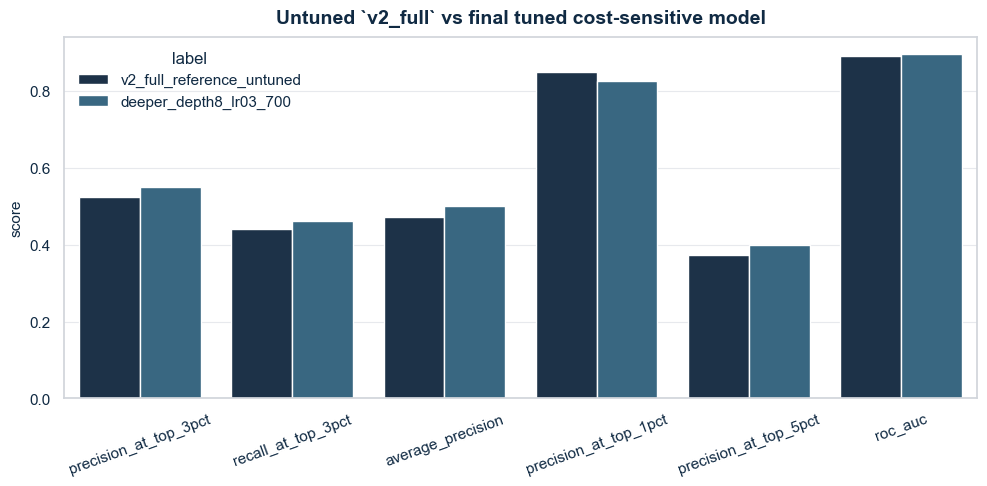

In [6]:
final_comparison = pd.DataFrame(
    [reference_row, best_targeted_result["row"]]
)[[
    "label",
    "precision_at_top_3pct",
    "recall_at_top_3pct",
    "average_precision",
    "precision_at_top_1pct",
    "precision_at_top_5pct",
    "roc_auc",
]]

display(final_comparison.style.hide(axis="index"))

delta_row = {
    "comparison": "best_targeted_minus_reference",
    "precision_at_top_3pct": best_targeted_result["row"]["precision_at_top_3pct"] - reference_row["precision_at_top_3pct"],
    "recall_at_top_3pct": best_targeted_result["row"]["recall_at_top_3pct"] - reference_row["recall_at_top_3pct"],
    "average_precision": best_targeted_result["row"]["average_precision"] - reference_row["average_precision"],
    "precision_at_top_1pct": best_targeted_result["row"]["precision_at_top_1pct"] - reference_row["precision_at_top_1pct"],
    "precision_at_top_5pct": best_targeted_result["row"]["precision_at_top_5pct"] - reference_row["precision_at_top_5pct"],
    "roc_auc": best_targeted_result["row"]["roc_auc"] - reference_row["roc_auc"],
}
display(pd.DataFrame([delta_row]).style.hide(axis="index"))

comparison_plot = final_comparison.melt(id_vars="label", var_name="metric", value_name="value")
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_plot, x="metric", y="value", hue="label")
plt.title("Untuned `v2_full` vs final tuned cost-sensitive model")
plt.xlabel("")
plt.ylabel("score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## SHAP For The Final Selected Model

This section keeps a compact global SHAP summary, adds a mean-absolute SHAP bar chart, and includes one local waterfall view for a high-risk validation row.


item,value
best_weight_label,weight_x0.65
best_targeted_label,deeper_depth8_lr03_700
rows_used_for_shap,1200
top_feature_for_dependence_view,TransactionDay


feature,mean_abs_shap
TransactionDay,0.241726
C13,0.175609
card6__count,0.175128
TransactionAmt_diff_mean_addr1,0.172034
TransactionDT,0.163226
C14,0.161787
D3,0.154957
card1__count,0.148973
C1,0.139489
C2,0.138348


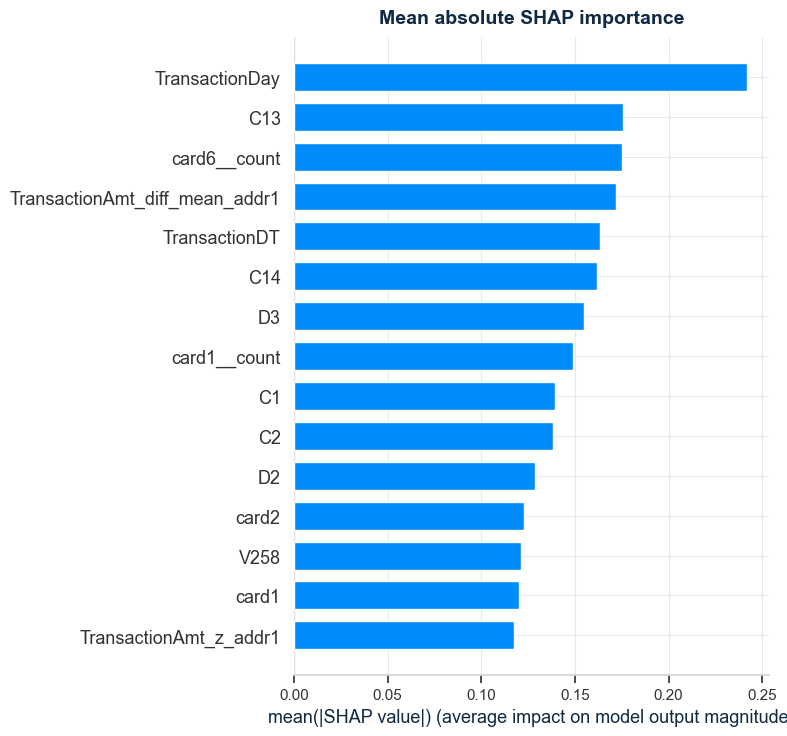

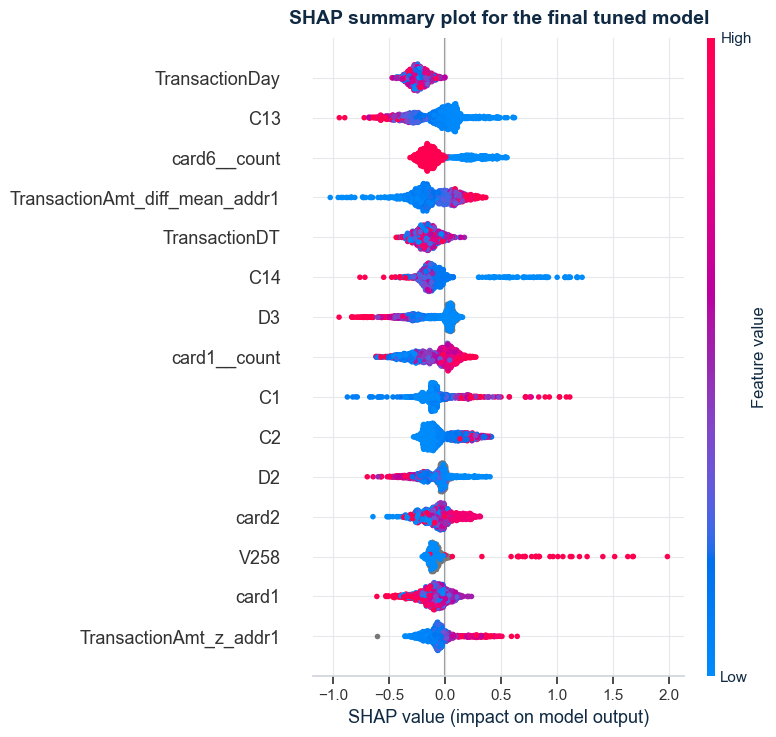

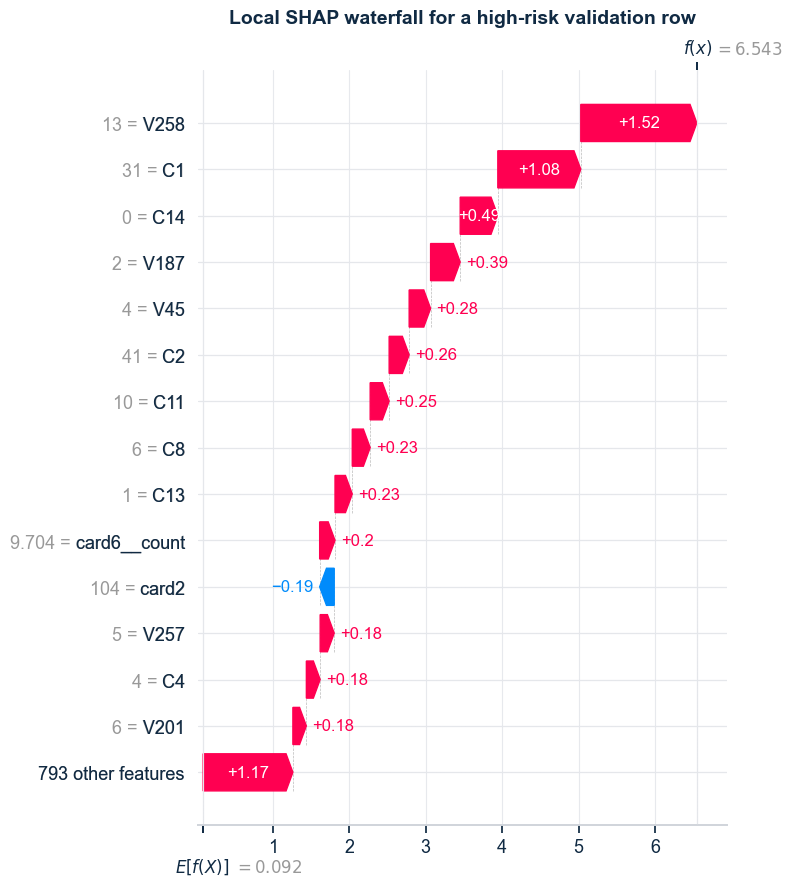

In [7]:
shap_pack = build_shap_diagnostics(
    best_targeted_result["model"],
    data_bundle.x_valid,
    data_bundle.y_valid,
    sample_size=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

display(
    pd.DataFrame(
        [
            {"item": "best_weight_label", "value": best_weight_row["label"]},
            {"item": "best_targeted_label", "value": best_targeted_row["label"]},
            {"item": "rows_used_for_shap", "value": shap_pack["row_count"]},
            {"item": "top_feature_for_dependence_view", "value": shap_pack["top_feature"]},
        ]
    ).style.hide(axis="index")
)

display(shap_pack["importance"].style.hide(axis="index"))

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_pack["shap_matrix"],
    shap_pack["x_sample"],
    plot_type="bar",
    show=False,
    max_display=15,
)
plt.title("Mean absolute SHAP importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_pack["shap_matrix"],
    shap_pack["x_sample"],
    show=False,
    max_display=15,
)
plt.title("SHAP summary plot for the final tuned model")
plt.tight_layout()
plt.show()

valid_score_series = pd.Series(best_targeted_result["valid_scores"], index=data_bundle.x_valid.index)
sample_scores = valid_score_series.loc[shap_pack["x_sample"].index]
local_row_position = int(sample_scores.to_numpy().argmax())

local_explanation = shap.Explanation(
    values=shap_pack["shap_matrix"][local_row_position],
    base_values=shap_pack["expected_value"],
    data=shap_pack["x_sample"].iloc[local_row_position].to_numpy(),
    feature_names=shap_pack["x_sample"].columns.tolist(),
)

shap.plots.waterfall(local_explanation, max_display=15, show=False)
plt.title("Local SHAP waterfall for a high-risk validation row")
plt.tight_layout()
plt.show()


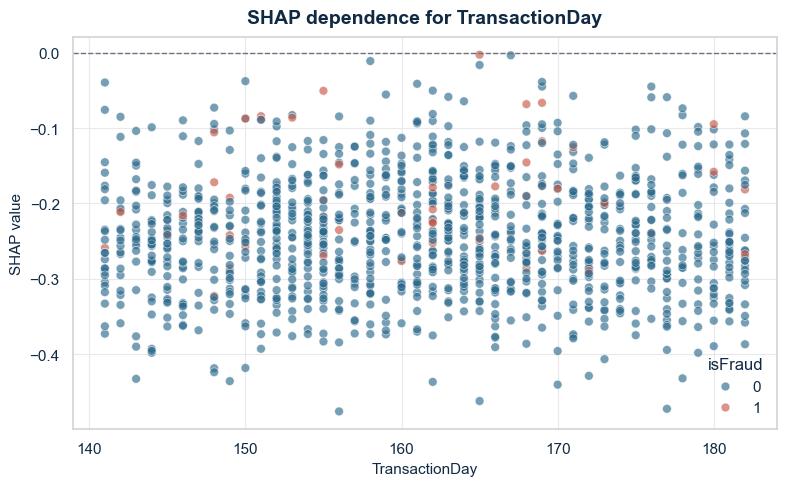

In [8]:
dependence_frame = shap_pack["dependence_frame"]
plt.figure(figsize=(8, 5))
if dependence_frame.empty:
    plt.text(0.5, 0.5, "No usable numeric values were available for the dependence view.", ha="center", va="center", wrap=True)
    plt.axis("off")
else:
    sns.scatterplot(
        data=dependence_frame,
        x=shap_pack["top_feature"],
        y="shap_value",
        hue="isFraud",
        palette={0: PLOT_COLORS["blue"], 1: PLOT_COLORS["coral"]},
        alpha=0.65,
        s=40,
    )
    plt.axhline(0, linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
    plt.title(f"SHAP dependence for {shap_pack['top_feature']}")
    plt.xlabel(shap_pack["top_feature"])
    plt.ylabel("SHAP value")
    plt.legend(title="isFraud")
plt.tight_layout()
plt.show()


In [9]:
weight_results.to_csv(OUTPUT_DIR / "cost_sensitive_weight_sweep.csv", index=False)
targeted_results.to_csv(OUTPUT_DIR / "cost_sensitive_targeted_runs.csv", index=False)

summary_payload = {
    "reference_run": reference_row,
    "best_weight_run": best_weight_row.to_dict(),
    "best_targeted_run": best_targeted_row.to_dict(),
    "delta_vs_reference": delta_row,
}
(OUTPUT_DIR / "cost_sensitive_tuning_summary.json").write_text(
    json.dumps(summary_payload, indent=2),
    encoding="utf-8",
)

print("Saved outputs/cost_sensitive_weight_sweep.csv")
print("Saved outputs/cost_sensitive_targeted_runs.csv")
print("Saved outputs/cost_sensitive_tuning_summary.json")


Saved outputs/cost_sensitive_weight_sweep.csv
Saved outputs/cost_sensitive_targeted_runs.csv
Saved outputs/cost_sensitive_tuning_summary.json


## Reading The Result

Main takeaways from this run:

- best new weight multiplier: `0.65`, with `scale_pos_weight = 17.63`
- `0.65` tied the old `0.6` reference on `Precision@Top3%` (`0.5229`) and slightly improved AP / ROC-AUC
- best targeted config: `deeper_depth8_lr03_700`
- final tuned result: `Precision@Top3% = 0.5500`, `Recall@Top3% = 0.4623`, `Average Precision = 0.5000`, `ROC-AUC = 0.8959`
- lift over untuned `v2_full`: `+0.0250` Precision@Top3%, `+0.0210` Recall@Top3%, `+0.0272` AP, `+0.0045` ROC-AUC
- top SHAP features: `TransactionDay`, `C13`, `card6__count`, `TransactionAmt_diff_mean_addr1`, `TransactionDT`
